# Data Cleaning & Dataset Construction — MedEmbed Training Triplets

**AAI-590 Capstone — Domain-Adapted Embeddings and Reranking in Enterprise Medical RAG**

This notebook is the execution counterpart to `01_eda.ipynb`. The EDA notebook *measured* the
raw [MedEmbed training triplet dataset](https://huggingface.co/datasets/abhinand/MedEmbed-training-triplets-v1)
(Balachandran, 2024) and deliberately changed nothing. This notebook implements every
"planned handling" entry from that notebook's summary table, validates the filters that the EDA
notebook flagged as unvalidated, and emits the frozen train/validation/test artifacts that
Modules 5–6 (bi-encoder fine-tuning, reranker fine-tuning, evaluation) consume.

**Findings carried over from EDA:**

| Diagnostic | Raw result | Handling implemented here |
|---|---|---|
| Anaphoric queries | 3.3% by lexical proxy (718 / 21,689) | §6 — entity-aware filter + hand-label validation |
| False-negative reuse | max 447 queries share one negative; 2,865 negatives reused 20+ times | §7 — bge-m3 similarity scoring, pair-level removal |
| Degenerate positives | 0.9% (243 / 27,590) | §5 — token-count floor, with cascade |
| Duplicate passages | not measured | §3 — normalized-text deduplication |
| Duplicate queries | not measured | §4 — consolidation into multi-positive queries |
| Query style | 75% keyword / 25% question | no action — split is stratified to preserve the ratio |
| Lexical overlap | mean Jaccard 0.090 | no action — verified unchanged post-cleaning in §10 |

**Two principles govern everything below.**

*Removals are recorded, not silent.* Every stage appends to a cleaning ledger with the count
removed and the reason, so the retention rate is auditable and the Data Summary section of the
report can be regenerated from `cleaning_ledger.csv` rather than re-derived by hand.

*Cleaning decisions are pair-level where the defect is pair-level.* A negative passage that is
reused 447 times is not globally bad — it is a bad negative *for the queries it actually
answers*. Deleting the passage outright would also delete it from the retrieval corpus, which
would make the eval corpus unrealistically easy. §7 therefore removes (query, negative) edges,
not passages.

In [1]:
import json
import re
import string
import unicodedata
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset

CONFIG = {
    "seed": 590,
    # §4 — a positive passage below this many whitespace tokens carries too little
    # signal to anchor a contrastive pair. Threshold inherited from EDA §5.
    "degenerate_min_tokens": 6,
    # §6 — only negatives attached to at least this many distinct queries are
    # candidates for false-negative screening. Inherited from EDA §4.
    "reuse_min_for_fn_check": 20,
    # §6 — a candidate negative is treated as a suspected false negative when its
    # similarity to the query exceeds this percentile of the TRUE positive-pair
    # similarity distribution. Calibrated, not hand-picked.
    "fn_threshold_percentile": 5.0,
    "embedding_model": "BAAI/bge-m3",
    "embedding_batch_size": 64,
    # §6 — cap negatives kept per query. Module 6 re-mines hard negatives from the
    # fine-tuned retriever, so the cap here only bounds Experiment A's input size.
    "max_negatives_per_query": 8,
    "min_negatives_per_query": 1,
    # §5 — size of the stratified sample hand-labeled to validate the filter.
    "anaphoric_validation_sample": 150,
    # §7 — corpus-level partition targets.
    "split_fractions": {"train": 0.80, "val": 0.10, "test": 0.10},
}

RNG = np.random.default_rng(CONFIG["seed"])

FIGURES_DIR = Path("../figures")
PROCESSED_DIR = Path("../data/processed")
ANNOTATION_DIR = Path("../data/annotation")
EXTERNAL_DIR = Path("../data/external")
CACHE_DIR = Path("../data/cache")
for d in (FIGURES_DIR, PROCESSED_DIR, ANNOTATION_DIR, EXTERNAL_DIR, CACHE_DIR):
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 110

# Every removal is appended here and written out as cleaning_ledger.csv in §8.
LEDGER = []


def record(stage, unit, removed, remaining, reason):
    """Append one row to the cleaning ledger and echo it."""
    LEDGER.append(
        {
            "stage": stage,
            "unit": unit,
            "removed": int(removed),
            "remaining": int(remaining),
            "reason": reason,
        }
    )
    print(f"[{stage}] removed {removed:,} {unit} -> {remaining:,} remain  ({reason})")

## 1. Load the raw dataset

We reload the same two configurations the EDA notebook used: `merged` (one row per query, with
its positive and its list of negatives) and `corpus` (the deduplicated passage store). The
headline counts are re-printed as a guard — if they do not match the EDA notebook, the upstream
dataset has been revised and every threshold below needs re-deriving before the numbers in the
report can be trusted.

In [2]:
merged = load_dataset("abhinand/MedEmbed-training-triplets-v1", "merged")["train"]
corpus = load_dataset("abhinand/MedEmbed-training-triplets-v1", "corpus")["train"]

df = merged.to_pandas()
corpus_df = corpus.to_pandas()

# HF list features arrive as numpy arrays; normalize to plain Python lists so that
# downstream set operations and JSON serialization behave predictably.
df["neg"] = df["neg"].apply(list)
df["neg_id"] = df["neg_id"].apply(list)

EXPECTED = {"queries": 21689, "passages": 27590}
print(f"Unique queries:        {len(df):,}   (EDA reported {EXPECTED['queries']:,})")
print(f"Unique corpus passages: {len(corpus_df):,}   (EDA reported {EXPECTED['passages']:,})")
print(f"Total (query, negative) pairs: {sum(len(n) for n in df['neg_id']):,}")

if len(df) != EXPECTED["queries"] or len(corpus_df) != EXPECTED["passages"]:
    print(
        "\nWARNING: counts differ from the EDA run. The upstream dataset has changed; "
        "re-run 01_eda.ipynb before trusting the thresholds in CONFIG."
    )

record("00_raw", "queries", 0, len(df), "baseline")
record("00_raw", "passages", 0, len(corpus_df), "baseline")

Unique queries:        21,689   (EDA reported 21,689)
Unique corpus passages: 27,590   (EDA reported 27,590)
Total (query, negative) pairs: 232,684
[00_raw] removed 0 queries -> 21,689 remain  (baseline)
[00_raw] removed 0 passages -> 27,590 remain  (baseline)


## 2. Structural integrity checks

Before applying any judgment-based filter, we check the things that are unambiguously broken:
missing or empty text, identifiers that point at nothing, duplicate query identifiers, and
queries whose positive passage also appears in their own negative list. That last case is the
most damaging of the four — a contrastive objective given the same passage as both the anchor's
positive and one of its negatives receives directly contradictory gradients for that pair.

These are corrections rather than curation decisions, so they run first and unconditionally.

In [3]:
corpus_ids = set(corpus_df["id"])
issues = {}

issues["null_query"] = df["query"].isna() | (df["query"].str.strip() == "")
issues["null_positive"] = df["pos"].isna() | (df["pos"].str.strip() == "")
issues["orphan_pos_id"] = ~df["pos_id"].isin(corpus_ids)
issues["no_negatives"] = df["neg_id"].apply(len) == 0
issues["self_negative"] = df.apply(lambda r: r["pos_id"] in set(r["neg_id"]), axis=1)
issues["duplicate_query_id"] = df["query_id"].duplicated(keep="first")

for name, mask in issues.items():
    print(f"{name:22s} {int(mask.sum()):>6,} rows ({mask.mean():.3%})")

orphan_neg_ids = {
    nid for neg_ids in df["neg_id"] for nid in neg_ids if nid not in corpus_ids
}
print(f"{'orphan_neg_id':22s} {len(orphan_neg_ids):>6,} distinct ids not present in corpus")

null_query                  0 rows (0.000%)
null_positive               0 rows (0.000%)
orphan_pos_id               0 rows (0.000%)
no_negatives                0 rows (0.000%)
self_negative               0 rows (0.000%)
duplicate_query_id          0 rows (0.000%)
orphan_neg_id               0 distinct ids not present in corpus


Repairs are applied at the narrowest scope that fixes the defect. A missing query text or a
positive that points outside the corpus invalidates the whole row, so those rows are dropped. A
self-negative or an orphaned negative identifier only invalidates that one edge, so the negative
is stripped and the query is retained.

In [4]:
# Row-level defects: the query is unusable.
drop_rows = (
    issues["null_query"]
    | issues["null_positive"]
    | issues["orphan_pos_id"]
    | issues["duplicate_query_id"]
)
n_before = len(df)
df = df[~drop_rows].reset_index(drop=True)
record(
    "01_structural", "queries", n_before - len(df), len(df),
    "null/empty text, orphaned pos_id, or duplicate query_id",
)

# Edge-level defects: strip the bad negative, keep the query.
pairs_before = sum(len(n) for n in df["neg_id"])


def clean_negatives(row):
    seen = set()
    kept_ids, kept_texts = [], []
    for nid, ntext in zip(row["neg_id"], row["neg"]):
        if nid == row["pos_id"] or nid not in corpus_ids or nid in seen:
            continue
        seen.add(nid)
        kept_ids.append(nid)
        kept_texts.append(ntext)
    return pd.Series({"neg_id": kept_ids, "neg": kept_texts})


df[["neg_id", "neg"]] = df.apply(clean_negatives, axis=1)
pairs_after = sum(len(n) for n in df["neg_id"])
record(
    "01_structural", "(query, negative) pairs", pairs_before - pairs_after, pairs_after,
    "negative equal to the positive, orphaned, or duplicated within the query",
)

# A query left with no negatives at all cannot form a triplet.
n_before = len(df)
df = df[df["neg_id"].apply(len) > 0].reset_index(drop=True)
record("01_structural", "queries", n_before - len(df), len(df), "no surviving negatives")

[01_structural] removed 0 queries -> 21,689 remain  (null/empty text, orphaned pos_id, or duplicate query_id)


[01_structural] removed 16,245 (query, negative) pairs -> 216,439 remain  (negative equal to the positive, orphaned, or duplicated within the query)
[01_structural] removed 0 queries -> 21,689 remain  (no surviving negatives)


## 3. Passage deduplication

The `corpus` configuration is deduplicated on exact string equality, which leaves
near-duplicates that differ only in whitespace, casing, or Unicode form. These matter twice
over. During training, two identifiers for the same text let the same passage act as a positive
in one pair and a negative in another. During evaluation, they let a passage seen in training
reappear in the test corpus under a different identifier, which quietly inflates test
performance — the exact leakage the corpus-level split in §7 exists to prevent.

We normalize aggressively for *matching* only (NFKC, case-folded, punctuation stripped,
whitespace collapsed) while keeping the original surface text of the canonical member, so the
text fed to the models is unmodified.

In [5]:
PUNCT_TABLE = str.maketrans("", "", string.punctuation)


def normalize_for_matching(text: str) -> str:
    """Aggressive normalization used ONLY to detect duplicates, never stored as content."""
    text = unicodedata.normalize("NFKC", str(text)).lower()
    text = text.translate(PUNCT_TABLE)
    return " ".join(text.split())


corpus_df["norm_text"] = corpus_df["text"].apply(normalize_for_matching)

# Canonical id per normalized text: the lexicographically smallest id, for determinism
# across re-runs regardless of dataset row order.
canonical = corpus_df.groupby("norm_text")["id"].min()
id_remap = {
    row_id: canonical[norm]
    for row_id, norm in zip(corpus_df["id"], corpus_df["norm_text"])
}
n_dupes = sum(1 for k, v in id_remap.items() if k != v)

group_sizes = corpus_df.groupby("norm_text").size()
print(f"Distinct normalized passages: {len(canonical):,} of {len(corpus_df):,} rows")
print(f"Redundant passage ids merged: {n_dupes:,} ({n_dupes / len(corpus_df):.2%})")
print(f"Largest duplicate group: {group_sizes.max()} identifiers for one passage")

corpus_df = (
    corpus_df[corpus_df["id"] == corpus_df["id"].map(id_remap)]
    .drop(columns=["norm_text"])
    .reset_index(drop=True)
)
record("02_dedup_pass", "passages", n_dupes, len(corpus_df),
       "normalized-text duplicates merged")

Distinct normalized passages: 27,571 of 27,590 rows
Redundant passage ids merged: 19 (0.07%)
Largest duplicate group: 4 identifiers for one passage
[02_dedup_pass] removed 19 passages -> 27,571 remain  (normalized-text duplicates merged)


In [6]:
# Propagate the remap into the query table, then re-strip any negative that has now
# collapsed onto the positive or onto another negative of the same query.
df["pos_id"] = df["pos_id"].map(id_remap)
pairs_before = sum(len(n) for n in df["neg_id"])


def remap_negatives(row):
    seen = set()
    kept_ids, kept_texts = [], []
    for nid, ntext in zip(row["neg_id"], row["neg"]):
        nid = id_remap[nid]
        if nid == row["pos_id"] or nid in seen:
            continue
        seen.add(nid)
        kept_ids.append(nid)
        kept_texts.append(ntext)
    return pd.Series({"neg_id": kept_ids, "neg": kept_texts})


df[["neg_id", "neg"]] = df.apply(remap_negatives, axis=1)
pairs_after = sum(len(n) for n in df["neg_id"])
record(
    "02_dedup_pass", "(query, negative) pairs", pairs_before - pairs_after, pairs_after,
    "negative collapsed onto the positive or another negative after remap",
)

n_before = len(df)
df = df[df["neg_id"].apply(len) > 0].reset_index(drop=True)
record("02_dedup_pass", "queries", n_before - len(df), len(df), "no surviving negatives")

[02_dedup_pass] removed 41 (query, negative) pairs -> 216,398 remain  (negative collapsed onto the positive or another negative after remap)
[02_dedup_pass] removed 0 queries -> 21,689 remain  (no surviving negatives)


## 4. Query deduplication and multi-positive consolidation

Because queries were generated by prompting an LLM over many source passages independently, the
same question text is produced repeatedly against different passages — *"What medication was
prescribed?"* is not tied to one document. Two distinct problems follow.

*The obvious one:* repeated query texts inflate the apparent dataset size and over-weight
whichever question phrasings the generator favored.

*The one that actually breaks evaluation:* if the same query text appears in both train and test
with different gold passages, the model was trained on that exact question. Worse, at test time
the gold label is arbitrary among several passages that all answer it, so a correct retrieval
can be scored as a miss.

We collapse each normalized query text to a single row. Where the duplicates disagreed on the
positive, we keep the full set as `alt_pos_ids` rather than discarding the alternatives — the
query genuinely has several correct answers, and the evaluation harness in Module 5 can credit
any of them instead of pretending one arbitrary choice is uniquely right.

Doing this *here* rather than as an edge in the partition graph of §8 matters. Linking queries
by shared text inside that graph chains unrelated queries together transitively — one shared
phrasing merges two passage clusters, those merge two more, and the components collapse into a
single blob that cannot be split 80/10/10 at all. Deduplicating first removes the cause instead
of propagating it.

In [7]:
df["norm_query"] = df["query"].apply(normalize_for_matching)
n_texts = df["norm_query"].nunique()
dupe_groups = df.groupby("norm_query").size()
print(f"Distinct normalized query texts: {n_texts:,} of {len(df):,} rows")
print(f"Query texts appearing more than once: {int((dupe_groups > 1).sum()):,}")
print(f"Largest duplicate group: {int(dupe_groups.max())} rows")

multi_pos = df.groupby("norm_query")["pos_id"].nunique()
print(
    f"Duplicate texts disagreeing on the positive: "
    f"{int((multi_pos > 1).sum()):,} (retained as alternative positives)"
)


def consolidate(group):
    group = group.sort_values("query_id")
    head = group.iloc[0]
    all_pos = sorted(set(group["pos_id"]))
    seen, neg_ids, neg_texts = set(), [], []
    for ids, texts in zip(group["neg_id"], group["neg"]):
        for nid, ntext in zip(ids, texts):
            if nid in all_pos or nid in seen:
                continue
            seen.add(nid)
            neg_ids.append(nid)
            neg_texts.append(ntext)
    return pd.Series(
        {
            "query_id": head["query_id"],
            "query": head["query"],
            "norm_query": head["norm_query"],
            "pos_id": all_pos[0],
            "alt_pos_ids": all_pos,
            "neg_id": neg_ids,
            "neg": neg_texts,
        }
    )


n_before = len(df)
df = (
    df.groupby("norm_query", sort=True)[df.columns.tolist()]
    .apply(consolidate)
    .reset_index(drop=True)
)
record(
    "03_dedup_query", "queries", n_before - len(df), len(df),
    "duplicate query text consolidated (alternative positives retained)",
)

n_before = len(df)
df = df[df["neg_id"].apply(len) > 0].reset_index(drop=True)
record("03_dedup_query", "queries", n_before - len(df), len(df), "no surviving negatives")
print(f"\nQueries with more than one acceptable positive: "
      f"{int((df['alt_pos_ids'].apply(len) > 1).sum()):,}")

Distinct normalized query texts: 21,303 of 21,689 rows
Query texts appearing more than once: 356
Largest duplicate group: 6 rows
Duplicate texts disagreeing on the positive: 356 (retained as alternative positives)


[03_dedup_query] removed 386 queries -> 21,303 remain  (duplicate query text consolidated (alternative positives retained))
[03_dedup_query] removed 0 queries -> 21,303 remain  (no surviving negatives)

Queries with more than one acceptable positive: 356


## 5. Degenerate positives

EDA §5 found that 0.9% of passages fall below six whitespace tokens — fragments like
*"Surgery was suggested."* or *"ASPECTS score was 7."* These are weak contrastive anchors: there
is too little lexical and semantic content for the encoder to align a query against, so the pair
contributes gradient noise rather than signal.

The asymmetry worth noting is that a fragment is only a problem as a **positive**. As a
*negative* it is harmless, and as a member of the retrieval corpus it is realistic — enterprise
document stores genuinely contain short fragments, and an evaluation corpus that excludes them
would understate the difficulty of the task. We therefore drop queries whose positive is
degenerate, but leave the fragments in the corpus.

In [8]:
corpus_df["token_count"] = corpus_df["text"].str.split().str.len()
degenerate_ids = set(
    corpus_df.loc[corpus_df["token_count"] < CONFIG["degenerate_min_tokens"], "id"]
)
print(
    f"Degenerate passages (< {CONFIG['degenerate_min_tokens']} tokens): "
    f"{len(degenerate_ids):,} of {len(corpus_df):,} ({len(degenerate_ids) / len(corpus_df):.2%})"
)

# A query survives if ANY of its acceptable positives clears the floor.
df["alt_pos_ids"] = df["alt_pos_ids"].apply(
    lambda ids: [i for i in ids if i not in degenerate_ids]
)
n_before = len(df)
df = df[df["alt_pos_ids"].apply(len) > 0].reset_index(drop=True)
df["pos_id"] = df["alt_pos_ids"].apply(lambda ids: ids[0])
record(
    "04_degenerate", "queries", n_before - len(df), len(df),
    f"every acceptable positive below {CONFIG['degenerate_min_tokens']} tokens",
)
print(
    "\nDegenerate passages are RETAINED in the corpus as distractors and as valid "
    "negatives; only their use as a training positive is removed."
)

Degenerate passages (< 6 tokens): 229 of 27,571 (0.83%)
[04_degenerate] removed 164 queries -> 21,139 remain  (every acceptable positive below 6 tokens)

Degenerate passages are RETAINED in the corpus as distractors and as valid negatives; only their use as a training positive is removed.


## 6. Anaphoric / context-dependent query filter

EDA §3 of `01_eda.ipynb` flagged 3.3% of queries with an explicitly provisional heuristic and committed to two
upgrades before the filter could be used: replace the hand-written seed list of clinical terms
with a real entity resource, and validate the result against hand labels. Both happen here.

**Definition.** A query is context-dependent when it contains a referring expression that has no
antecedent inside the query itself (*the patient*, *his*, *her*, *the above*) together with an
underspecified predicate (*outcome*, *condition*, *result*), **and** mentions no specific
clinical entity that would pin it to a particular passage. *"What was the outcome of the
patient's treatment?"* satisfies all three and could correctly describe hundreds of passages.
*"What was the outcome of the patient's carotid endarterectomy?"* does not, because the named
procedure disambiguates it.

**Why this matters more for evaluation than for training.** In training, an ambiguous query
teaches an arbitrary association — recoverable noise. In evaluation it is worse than noise: the
gold label is one of many equally correct passages, so Recall@k and nDCG@10 penalize the model
for retrieving a passage that a clinician would accept. Leaving these in the test set makes the
headline metrics in the Results section unreliable in a way no amount of model improvement can
fix.

**Entity detection.** The filter tries three sources in order of preference, and reports which
one it used, because the flagged rate is not comparable across them.

In [9]:
# Generic mentions that a clinical NER model will happily tag but that do NOT
# disambiguate a query. "The patient's condition" contains two entity mentions and is
# still unanswerable in isolation, so these are excluded from the specificity test.
GENERIC_ENTITY_TERMS = {
    "patient", "patients", "condition", "conditions", "outcome", "outcomes",
    "symptom", "symptoms", "treatment", "treatments", "therapy", "therapies",
    "diagnosis", "disease", "illness", "medication", "medications", "drug", "drugs",
    "hospital", "discharge", "admission", "procedure", "surgery", "operation",
    "history", "followup", "follow up", "care", "doctor", "physician", "clinician",
    "test", "tests", "result", "results", "management", "complication",
    "complications", "case", "study", "report", "problem", "problems",
}


def build_entity_detector():
    """Return (fn(list[str]) -> list[bool], source_name).

    Preference order: scispaCy clinical NER > MeSH/UMLS gazetteer > EDA seed regex.
    """
    try:
        import spacy

        nlp = spacy.load("en_core_sci_sm", disable=["lemmatizer"])

        def detect(texts):
            out = []
            for doc in nlp.pipe(list(texts), batch_size=256):
                out.append(
                    any(
                        normalize_for_matching(ent.text) not in GENERIC_ENTITY_TERMS
                        and len(ent.text.strip()) > 2
                        for ent in doc.ents
                    )
                )
            return out

        return detect, "scispacy:en_core_sci_sm"
    except Exception as exc:  # noqa: BLE001 - any failure falls through to gazetteer
        print(f"scispaCy unavailable ({type(exc).__name__}); trying MeSH gazetteer.")

    gazetteer_path = EXTERNAL_DIR / "mesh_terms.txt"
    if gazetteer_path.exists():
        terms = {
            normalize_for_matching(line)
            for line in gazetteer_path.read_text(encoding="utf-8").splitlines()
            if len(line.strip()) > 3
        }
        terms -= GENERIC_ENTITY_TERMS
        pattern = re.compile(
            r"\b(" + "|".join(sorted(map(re.escape, terms), key=len, reverse=True)) + r")\b"
        )

        def detect(texts):
            return [bool(pattern.search(normalize_for_matching(t))) for t in texts]

        return detect, f"mesh_gazetteer:{len(terms)}_terms"

    print(
        "WARNING: no entity resource found. Falling back to the EDA seed regex. The "
        "flagged rate below is NOT the validated production rate — install scispaCy "
        "(pip install scispacy + the en_core_sci_sm wheel) or place a MeSH term list at "
        f"{gazetteer_path} before reporting these numbers."
    )
    seed = re.compile(
        r"\b(mg|ml|therapy|syndrome|scale|score|surgery|diagnosis|treatment|"
        r"disease|infection|tumor|cancer|fracture|artery|vein|nerve|biopsy|"
        r"lesion|carcinoma|virus|bacteria|antibiotic|chemotherapy|radiotherapy)\b",
        re.IGNORECASE,
    )

    def detect(texts):
        return [bool(seed.search(t)) for t in texts]

    return detect, "eda_seed_regex (UNVALIDATED)"


detect_entities, ENTITY_SOURCE = build_entity_detector()
print(f"\nEntity detection source: {ENTITY_SOURCE}")


Entity detection source: scispacy:en_core_sci_sm


/Users/aleenagigi/Personal Projects/Masters/Domain-Adapted-Embeddings-and-Reranking-in-Enterprise-Medical-RAG/.venv311/lib/python3.11/site-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


In [10]:
REFERRING_EXPR = re.compile(
    r"\bthe patient'?s?\b|\bthis patient\b|\bthe above\b|\bthe case\b"
    r"|\bhis\b|\bher\b|\bhim\b|\btheir\b|\bthey\b",
    re.IGNORECASE,
)
UNDERSPECIFIED_PREDICATE = re.compile(
    r"\boutcome\b|\bcondition\b|\bfare\b|\bresult\b|\bafter\b|\bfollowing\b"
    r"|\bprognosis\b|\bfollow[- ]?up\b|\bhistory\b|\bstatus\b",
    re.IGNORECASE,
)

queries = df["query"].str.strip().tolist()
has_referring = [bool(REFERRING_EXPR.search(q)) for q in queries]
has_underspecified = [bool(UNDERSPECIFIED_PREDICATE.search(q)) for q in queries]
has_entity = detect_entities(queries)

df["has_referring"] = has_referring
df["has_entity"] = has_entity
df["is_anaphoric"] = [
    r and u and not e for r, u, e in zip(has_referring, has_underspecified, has_entity)
]

flag_rate = df["is_anaphoric"].mean()
print(f"Flagged as context-dependent: {flag_rate:.2%} ({int(df['is_anaphoric'].sum()):,} queries)")
print("EDA lexical proxy reported 3.30%; a stricter entity test moves this number.\n")

print("Sample of FLAGGED queries:")
for q in df.loc[df["is_anaphoric"], "query"].head(6):
    print(f"  x {q.strip()}")
print("\nSample of queries with a referring expression but RETAINED (entity disambiguates):")
for q in df.loc[df["has_referring"] & ~df["is_anaphoric"], "query"].head(6):
    print(f"  + {q.strip()}")

if flag_rate > 0.15:
    print(
        "\nWARNING: flagged rate exceeds 15%. Removing this much data on an unvalidated "
        "filter is not defensible — complete the validation below before proceeding."
    )

Flagged as context-dependent: 1.07% (227 queries)
EDA lexical proxy reported 3.30%; a stricter entity test moves this number.

Sample of FLAGGED queries:
  x Can the patient eat normally after surgery?
  x Can the patient's condition be managed with medication?
  x Can the patient's condition be managed without medication?
  x Can you describe the patient's condition after the procedure?
  x Can you describe the patient's condition at 6-month follow-up?
  x Can you describe the patient's condition at discharge?

Sample of queries with a referring expression but RETAINED (entity disambiguates):
  + Adjustments made to the patient's treatment regimen
  + alternative treatments for this patient
  + Autopsy findings of the patient's coronary arteries
  + Barium swallow results for the patient
  + Can the patient discontinue thyrotropin-suppressive therapy?
  + Can the patient perform strenuous activities after discharge?


### 6.1 Validation against hand labels

A filter that removes training data has to be measured, not asserted. We draw a stratified
sample — half flagged, half unflagged — so that both precision (of the flagged set) and recall
(against genuinely context-dependent queries the filter missed) are estimable from one labeling
pass. Sampling only from the flagged set would give precision and tell us nothing about misses.

The cell writes `anaphoric_sample.csv` with an empty `label` column. Two team members label
independently (`1` = unanswerable without the source document, `0` = answerable in isolation),
and the completed file is saved as `anaphoric_labels.csv`. Re-running the cell then computes the
metrics. Until that file exists the cell reports the pending state rather than fabricating a
score.

In [11]:
sample_path = ANNOTATION_DIR / "anaphoric_sample.csv"
labels_path = ANNOTATION_DIR / "anaphoric_labels.csv"
n_each = CONFIG["anaphoric_validation_sample"] // 2

if not sample_path.exists():
    flagged_pool = df.index[df["is_anaphoric"]].to_numpy()
    unflagged_pool = df.index[~df["is_anaphoric"]].to_numpy()
    picks = np.concatenate(
        [
            RNG.choice(flagged_pool, size=min(n_each, len(flagged_pool)), replace=False),
            RNG.choice(unflagged_pool, size=min(n_each, len(unflagged_pool)), replace=False),
        ]
    )
    sample = df.loc[picks, ["query_id", "query", "is_anaphoric"]].copy()
    sample = sample.rename(columns={"is_anaphoric": "predicted"})
    sample["label"] = ""  # 1 = context-dependent, 0 = self-contained
    sample = sample.sample(frac=1.0, random_state=CONFIG["seed"])  # hide the strata
    sample.to_csv(sample_path, index=False)
    print(f"Wrote {len(sample)} rows for annotation -> {sample_path}")

if labels_path.exists():
    labeled = pd.read_csv(labels_path)
    labeled = labeled[labeled["label"].notna()]
    y_true = labeled["label"].astype(int).to_numpy()
    y_pred = labeled["predicted"].astype(bool).astype(int).to_numpy()

    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())

    precision = tp / (tp + fp) if tp + fp else float("nan")
    recall = tp / (tp + fn) if tp + fn else float("nan")
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else float("nan")

    print(f"Hand-labeled sample: n = {len(labeled)}")
    print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
    print(f"  Precision {precision:.3f} | Recall {recall:.3f} | F1 {f1:.3f}")
    ANAPHORIC_VALIDATION = {
        "n": int(len(labeled)), "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "precision": precision, "recall": recall, "f1": f1,
    }
    if precision < 0.80:
        print(
            "\nPrecision below 0.80: the filter is discarding self-contained queries. "
            "Tighten REFERRING_EXPR or widen the entity test before applying it."
        )
else:
    ANAPHORIC_VALIDATION = None
    print(
        f"\nPENDING: {labels_path.name} not found. Label {sample_path.name} "
        "(1 = context-dependent, 0 = self-contained) and re-run this cell. "
        "The precision/recall figures reported in the Data Summary section come from here."
    )

Wrote 150 rows for annotation -> ../data/annotation/anaphoric_sample.csv

PENDING: anaphoric_labels.csv not found. Label anaphoric_sample.csv (1 = context-dependent, 0 = self-contained) and re-run this cell. The precision/recall figures reported in the Data Summary section come from here.


In [12]:
n_before = len(df)
df = df[~df["is_anaphoric"]].reset_index(drop=True)
df = df.drop(columns=["has_referring", "has_entity", "is_anaphoric"])
record(
    "05_anaphoric", "queries", n_before - len(df), len(df),
    f"context-dependent query (entity source: {ENTITY_SOURCE})",
)

[05_anaphoric] removed 227 queries -> 20,912 remain  (context-dependent query (entity source: scispacy:en_core_sci_sm))


## 7. False-negative screening

This is the largest and most consequential cleaning step. EDA §4 showed that negatives were
mined automatically, and that one passage is attached as a "negative" to 447 different queries
while roughly 13% of unique negatives are reused by 20 or more. Reuse at that scale is a
signature of generic filler — boilerplate discharge and follow-up language that got sampled
repeatedly — and some of those passages genuinely answer some of the queries they are labeled
against.

A false negative is the most expensive label error in contrastive training. The loss actively
pushes the query embedding *away* from a passage that should be retrieved, so the model is
trained toward the specific mistake we then measure. The reranker in Experiment B inherits the
same corruption, since it consumes the retriever's candidate lists.

**Two decisions define the method.**

*Score pairs, not passages.* The unit of removal is the (query, negative) edge. A boilerplate
passage stays in the corpus and stays a valid negative for the queries it does not answer —
deleting it wholesale would shrink the retrieval corpus and make evaluation easier than the
deployment setting it is meant to model.

*Calibrate the threshold against the positive distribution rather than picking a round number.*
We encode each candidate query's true positive with the same model and set the cutoff at the
5th percentile of that similarity distribution. The rule this expresses: a passage labeled
negative that scores at least as relevant as the weakest 5% of *known-correct* pairs is more
likely a mislabeled positive than a hard negative. The threshold is therefore a property of the
dataset and the encoder, and it moves if either changes.

Scoring uses **stock** `BAAI/bge-m3`, not a fine-tuned checkpoint. Using a model fine-tuned on
this data to decide which of this data to keep would be circular — the model's errors would
determine which of its errors get corrected.

In [13]:
neg_reuse = Counter()
for neg_ids in df["neg_id"]:
    neg_reuse.update(neg_ids)

threshold_reuse = CONFIG["reuse_min_for_fn_check"]
high_reuse_ids = {nid for nid, c in neg_reuse.items() if c >= threshold_reuse}

candidate_pairs = [
    (qid, nid)
    for qid, neg_ids in zip(df["query_id"], df["neg_id"])
    for nid in neg_ids
    if nid in high_reuse_ids
]
total_pairs = sum(len(n) for n in df["neg_id"])

print(f"Unique negatives: {len(neg_reuse):,}")
print(f"Reused by >= {threshold_reuse} queries: {len(high_reuse_ids):,} "
      f"({len(high_reuse_ids) / len(neg_reuse):.1%})")
print(f"Candidate (query, negative) pairs to score: {len(candidate_pairs):,} "
      f"of {total_pairs:,} total ({len(candidate_pairs) / total_pairs:.1%})")
print(f"Most-reused negative is attached to {max(neg_reuse.values())} queries")

SCREENING_ENABLED = len(candidate_pairs) > 0
if not SCREENING_ENABLED:
    print(
        f"\nNo negative is reused by {threshold_reuse}+ queries after the upstream "
        "filters, so there is nothing to screen. This is unexpected on the full dataset "
        "— check that §1 loaded all 21,689 queries before reporting a zero here."
    )

Unique negatives: 21,692
Reused by >= 20 queries: 2,501 (11.5%)
Candidate (query, negative) pairs to score: 93,403 of 210,509 total (44.4%)
Most-reused negative is attached to 316 queries


In [14]:
from sentence_transformers import SentenceTransformer

id_to_text = dict(zip(corpus_df["id"], corpus_df["text"]))
qid_to_query = dict(zip(df["query_id"], df["query"]))
qid_to_pos_id = dict(zip(df["query_id"], df["pos_id"]))

candidate_qids = sorted({qid for qid, _ in candidate_pairs})
candidate_nids = sorted({nid for _, nid in candidate_pairs})
candidate_pos_ids = sorted({qid_to_pos_id[qid] for qid in candidate_qids})
passages_to_encode = sorted(set(candidate_nids) | set(candidate_pos_ids))

cache_file = CACHE_DIR / "bge_m3_screening_embeddings.npz"


def encode_all():
    model = SentenceTransformer(CONFIG["embedding_model"])
    q_emb = model.encode(
        [qid_to_query[q] for q in candidate_qids],
        batch_size=CONFIG["embedding_batch_size"],
        normalize_embeddings=True,
        show_progress_bar=True,
        convert_to_numpy=True,
    )
    p_emb = model.encode(
        [id_to_text[p] for p in passages_to_encode],
        batch_size=CONFIG["embedding_batch_size"],
        normalize_embeddings=True,
        show_progress_bar=True,
        convert_to_numpy=True,
    )
    return q_emb, p_emb


def load_or_encode():
    if cache_file.exists():
        cached = np.load(cache_file, allow_pickle=True)
        if (
            list(cached["query_ids"]) == candidate_qids
            and list(cached["passage_ids"]) == passages_to_encode
        ):
            print(f"Loaded cached embeddings from {cache_file}")
            return cached["query_emb"], cached["passage_emb"]
        print("Cache key mismatch (upstream filters changed); re-encoding.")
    q_emb, p_emb = encode_all()
    np.savez(cache_file, query_emb=q_emb, passage_emb=p_emb,
             query_ids=candidate_qids, passage_ids=passages_to_encode)
    return q_emb, p_emb


if SCREENING_ENABLED:
    query_emb, passage_emb = load_or_encode()
    q_index = {qid: i for i, qid in enumerate(candidate_qids)}
    p_index = {pid: i for i, pid in enumerate(passages_to_encode)}
    print(f"Encoded {len(candidate_qids):,} queries and "
          f"{len(passages_to_encode):,} passages "
          f"({query_emb.shape[1]}-d, L2-normalized)")
else:
    query_emb = passage_emb = None
    q_index = p_index = {}
    print("Screening disabled; no encoding performed.")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/317 [00:00<?, ?it/s]

Batches:   0%|          | 0/321 [00:00<?, ?it/s]

Encoded 20,229 queries and 20,517 passages (1024-d, L2-normalized)


True positive-pair similarity: mean=0.556, p5=0.400, p50=0.556
Candidate negative similarity:  mean=0.537, p50=0.529, max=0.883

Calibrated threshold (p5 of positives): 0.400
Suspected false negatives: 90,960 of 93,403 scored pairs (97.4%); 43.21% of all (query, negative) pairs



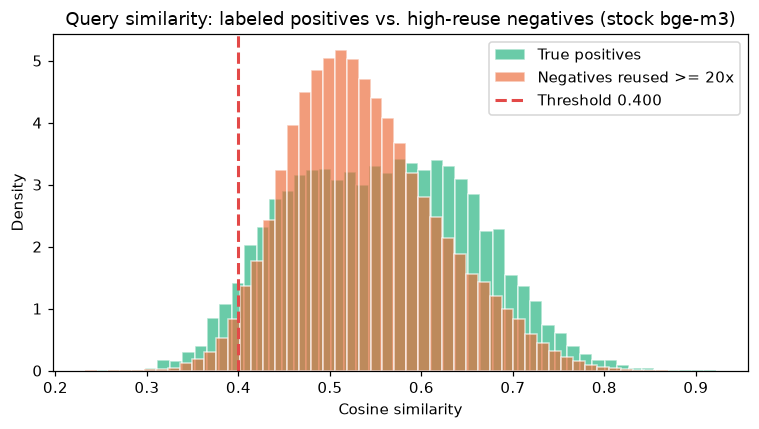

In [15]:
if SCREENING_ENABLED:
    # Embeddings are L2-normalized, so the dot product is cosine similarity.
    pos_sims = np.array(
        [
            float(query_emb[q_index[qid]] @ passage_emb[p_index[qid_to_pos_id[qid]]])
            for qid in candidate_qids
        ]
    )
    pair_sims = np.array(
        [
            float(query_emb[q_index[qid]] @ passage_emb[p_index[nid]])
            for qid, nid in candidate_pairs
        ]
    )
    FN_THRESHOLD = float(np.percentile(pos_sims, CONFIG["fn_threshold_percentile"]))
    suspected = pair_sims >= FN_THRESHOLD
else:
    pos_sims = pair_sims = np.array([])
    FN_THRESHOLD = float("inf")
    suspected = np.zeros(0, dtype=bool)

if SCREENING_ENABLED:
    print(f"True positive-pair similarity: mean={pos_sims.mean():.3f}, "
       f"p5={np.percentile(pos_sims, 5):.3f}, p50={np.percentile(pos_sims, 50):.3f}")
    print(f"Candidate negative similarity:  mean={pair_sims.mean():.3f}, "
          f"p50={np.percentile(pair_sims, 50):.3f}, max={pair_sims.max():.3f}")
    print(f"\nCalibrated threshold (p{CONFIG['fn_threshold_percentile']:g} of positives): "
          f"{FN_THRESHOLD:.3f}")
    print(f"Suspected false negatives: {int(suspected.sum()):,} of "
          f"{len(candidate_pairs):,} scored pairs ({suspected.mean():.1%}); "
          f"{suspected.sum() / total_pairs:.2%} of all (query, negative) pairs")

    # A screening step that flags most of what it inspects is not screening, it is
    # deleting. Surface that rather than let it pass as a result.
    if suspected.mean() > 0.40:
        print(
            "\nWARNING: over 40% of scored pairs were flagged. Either the reuse "
            "threshold is admitting ordinary hard negatives, or the encoder is not "
            "separating positives from negatives on this data. Inspect the histogram "
            "below before applying these removals."
        )

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(pos_sims, bins=50, alpha=0.65, label="True positives", color="#1baf7a",
            edgecolor="white", density=True)
    ax.hist(pair_sims, bins=50, alpha=0.65,
            label=f"Negatives reused >= {threshold_reuse}x",
            color="#eb6834", edgecolor="white", density=True)
    ax.axvline(FN_THRESHOLD, color="#e34948", linestyle="--", linewidth=2,
               label=f"Threshold {FN_THRESHOLD:.3f}")
    ax.set_title(
        "Query similarity: labeled positives vs. high-reuse negatives (stock bge-m3)"
    )
    ax.set_xlabel("Cosine similarity")
    ax.set_ylabel("Density")
    ax.legend()
    fig.tight_layout()
    fig.savefig(f"{FIGURES_DIR}/fig5_false_negative_threshold.png", dpi=150)
    plt.show()
else:
    print("No pairs scored; skipping the threshold calibration plot.")

The overlap between the two distributions is the finding: high-reuse negatives that land to
the right of the threshold are scoring as well against their query as genuine positives do. The
examples below are printed so the removals can be inspected rather than trusted — a handful of
the highest-scoring pairs should read as passages that plainly answer the query.

In [16]:
order = np.argsort(-pair_sims) if SCREENING_ENABLED else np.array([], dtype=int)
print("Highest-scoring suspected false negatives:\n")
for idx in order[:5]:
    qid, nid = candidate_pairs[idx]
    print(f"  sim={pair_sims[idx]:.3f} | reuse={neg_reuse[nid]}x")
    print(f"    query:    {qid_to_query[qid].strip()}")
    print(f"    negative: {id_to_text[nid][:170]}")
    print()

print("Lowest-scoring high-reuse negatives (retained as genuine hard negatives):\n")
for idx in order[-3:]:
    qid, nid = candidate_pairs[idx]
    print(f"  sim={pair_sims[idx]:.3f} | reuse={neg_reuse[nid]}x")
    print(f"    query:    {qid_to_query[qid].strip()}")
    print(f"    negative: {id_to_text[nid][:170]}")
    print()

Highest-scoring suspected false negatives:

  sim=0.883 | reuse=81x
    query:    What follow-up was recommended for the patient after being discharged?
    negative: The patient was advised to continue with follow-up care after discharge.

  sim=0.865 | reuse=157x
    query:    Follow-up instructions for the patient
    negative: Follow-up care instructions were provided to the patient.

  sim=0.863 | reuse=35x
    query:    What were the patient's follow-up instructions after discharge?
    negative: The patient was discharged and provided with follow-up instructions.

  sim=0.862 | reuse=143x
    query:    What follow-up care plan was scheduled for the patient after discharge?
    negative: The patient was discharged with a plan for follow-up care.

  sim=0.860 | reuse=228x
    query:    Follow-up care recommendation
    negative: Follow-up care was advised.

Lowest-scoring high-reuse negatives (retained as genuine hard negatives):

  sim=0.241 | reuse=38x
    query:    What was the

In [17]:
drop_edges = {
    (qid, nid) for (qid, nid), flag in zip(candidate_pairs, suspected) if flag
}
pairs_before = sum(len(n) for n in df["neg_id"])


def drop_suspected(row):
    kept_ids, kept_texts = [], []
    for nid, ntext in zip(row["neg_id"], row["neg"]):
        if (row["query_id"], nid) in drop_edges:
            continue
        kept_ids.append(nid)
        kept_texts.append(ntext)
    return pd.Series({"neg_id": kept_ids, "neg": kept_texts})


df[["neg_id", "neg"]] = df.apply(drop_suspected, axis=1)
pairs_after = sum(len(n) for n in df["neg_id"])
record(
    "06_false_negative", "(query, negative) pairs", pairs_before - pairs_after, pairs_after,
    (
        f"stock bge-m3 similarity >= {FN_THRESHOLD:.3f} "
        f"(p{CONFIG['fn_threshold_percentile']:g} of true positive pairs)"
        if SCREENING_ENABLED
        else "screening skipped: no negative met the reuse threshold"
    ),
)

n_before = len(df)
df = df[df["neg_id"].apply(len) >= CONFIG["min_negatives_per_query"]].reset_index(drop=True)
record(
    "06_false_negative", "queries", n_before - len(df), len(df),
    f"fewer than {CONFIG['min_negatives_per_query']} negatives remaining",
)

[06_false_negative] removed 90,960 (query, negative) pairs -> 119,549 remain  (stock bge-m3 similarity >= 0.400 (p5 of true positive pairs))
[06_false_negative] removed 310 queries -> 20,602 remain  (fewer than 1 negatives remaining)


### 7.1 Capping negatives per query

Training pairs are capped so that a handful of queries with long negative lists do not dominate
the epoch. The cap is a *sampling* decision, not a quality decision, so the selection is a
seeded uniform draw rather than a similarity-ranked one — deliberately keeping the hardest
surviving negatives here would pre-empt the hard-negative mining that Module 6 performs against
the fine-tuned retriever, and would make Experiment A's improvement partly attributable to
negative selection rather than to fine-tuning.

The uncapped list is preserved in a separate column so that the mining step in Module 6 can
recover it without re-running this notebook.

In [18]:
df["neg_id_uncapped"] = df["neg_id"]
cap = CONFIG["max_negatives_per_query"]
pairs_before = sum(len(n) for n in df["neg_id"])


def cap_negatives(row):
    ids = row["neg_id"]
    if len(ids) <= cap:
        return pd.Series({"neg_id": ids, "neg": row["neg"]})
    keep = sorted(RNG.choice(len(ids), size=cap, replace=False).tolist())
    return pd.Series(
        {"neg_id": [ids[i] for i in keep], "neg": [row["neg"][i] for i in keep]}
    )


df[["neg_id", "neg"]] = df.apply(cap_negatives, axis=1)
pairs_after = sum(len(n) for n in df["neg_id"])
record(
    "07_cap", "(query, negative) pairs", pairs_before - pairs_after, pairs_after,
    f"capped at {cap} negatives per query (seeded uniform sample; full list retained)",
)

lengths = df["neg_id"].apply(len)
print(f"\nNegatives per query after capping: mean={lengths.mean():.2f}, "
      f"min={lengths.min()}, max={lengths.max()}")

post_reuse = Counter(nid for ids in df["neg_id"] for nid in ids)
print(f"Max negative reuse after screening: {max(post_reuse.values())} "
      f"(was {max(neg_reuse.values())} before)")

[07_cap] removed 3,974 (query, negative) pairs -> 115,575 remain  (capped at 8 negatives per query (seeded uniform sample; full list retained))

Negatives per query after capping: mean=5.61, min=1, max=8
Max negative reuse after screening: 19 (was 316 before)


## 8. Corpus-level train / validation / test partitioning

A random row-wise split would leak. Multiple queries are generated from the same source passage,
so a random assignment puts sibling queries on both sides of the boundary — at test time the
model is asked to retrieve a passage it was explicitly trained to retrieve for a near-identical
query, and the reported Recall@k overstates what the system would do on genuinely unseen
documents. That is precisely the failure mode this project's evaluation is supposed to detect,
so the split has to prevent it structurally rather than by inspection.

**Method.** Build a bipartite graph linking each query to its positive passage, and additionally
link queries sharing identical normalized text. Take connected components under union-find and
assign whole components to splits. A component is the transitive closure of "shares a positive
passage or is the same question," so no passage can be a positive on both sides of a split, and
no query text can appear on both sides.

**Assignment.** Components are sorted by size descending and each is given to whichever split is
furthest below its target quota. Greedy largest-first is used because component sizes are
heavily skewed — random assignment of a few very large components produces splits that miss the
80/10/10 target by several points.

**Retrieval corpus per split.** Passages that are positives inherit their component's split.
Passages that are only ever negatives belong to no component and become a shared distractor
pool available to every split. So the test-time corpus is *test positives + shared distractors*:
large enough to be a realistic retrieval problem, with a guarantee that no test positive was
seen during training.

In [19]:
class UnionFind:
    def __init__(self):
        self.parent = {}

    def find(self, x):
        self.parent.setdefault(x, x)
        root = x
        while self.parent[root] != root:
            root = self.parent[root]
        while self.parent[x] != root:  # path compression
            self.parent[x], x = root, self.parent[x]
        return root

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.parent[rb] = ra


uf = UnionFind()
for qid, pos_ids in zip(df["query_id"], df["alt_pos_ids"]):
    for pid in pos_ids:
        uf.union(("q", qid), ("p", pid))

components = defaultdict(list)
for qid in df["query_id"]:
    components[uf.find(("q", qid))].append(qid)

comp_sizes = pd.Series([len(v) for v in components.values()])
max_share = float(comp_sizes.max()) / len(df)
print(f"Connected components: {len(components):,} covering {len(df):,} queries")
print(f"Component size: mean={comp_sizes.mean():.2f}, median={comp_sizes.median():.0f}, "
      f"max={comp_sizes.max()}")
print(f"Singleton components: {(comp_sizes == 1).sum():,} ({(comp_sizes == 1).mean():.1%})")
print(f"Largest component: {comp_sizes.max()} queries ({max_share:.2%} of the dataset)")

# Granularity check. Components are indivisible, so the smallest split cannot be sized
# more finely than the largest component. If one component is bigger than the val or
# test target, the 80/10/10 proportions are simply unreachable and the report has to
# state the achieved proportions instead.
smallest_target = min(CONFIG["split_fractions"].values())
if max_share > smallest_target:
    print(
        f"\nWARNING: the largest component ({max_share:.2%}) exceeds the smallest split "
        f"target ({smallest_target:.0%}). Exact 80/10/10 is unattainable; the achieved "
        "proportions below are what the Data Summary section must report."
    )
if max_share > 0.5:
    raise RuntimeError(
        "A single component covers over half the queries — passage sharing has chained "
        "the graph into one blob and no leakage-safe split exists. Check that query "
        "deduplication in §4 ran before this cell."
    )

Connected components: 20,086 covering 20,602 queries
Component size: mean=1.03, median=1, max=5
Singleton components: 19,587 (97.5%)
Largest component: 5 queries (0.02% of the dataset)


In [20]:
fracs = CONFIG["split_fractions"]
targets = {name: frac * len(df) for name, frac in fracs.items()}
assigned_counts = {name: 0 for name in fracs}
query_split = {}

# Deterministic order: largest first, ties broken by component key.
ordered = sorted(components.items(), key=lambda kv: (-len(kv[1]), str(kv[0])))
for root, qids in ordered:
    name = max(assigned_counts, key=lambda k: targets[k] - assigned_counts[k])
    assigned_counts[name] += len(qids)
    for qid in qids:
        query_split[qid] = name

df["split"] = df["query_id"].map(query_split)

summary = (
    df.groupby("split")
    .agg(
        queries=("query_id", "size"),
        positives=("pos_id", "nunique"),
        negative_pairs=("neg_id", lambda s: sum(len(x) for x in s)),
    )
    .reindex(list(fracs))
    .fillna(0)
    .astype(int)
)
summary["share"] = summary["queries"] / len(df)
summary["target"] = [fracs[i] for i in summary.index]
print(summary.to_string(float_format=lambda v: f"{v:.4f}"))

max_dev = float((summary["share"] - summary["target"]).abs().max())
# Tolerance is bounded below by the largest indivisible component, not by a wish.
tolerance = max(0.01, max_share)
print(f"\nLargest deviation from target: {max_dev:.4f} (tolerance {tolerance:.4f})")
assert (summary["queries"] > 0).all(), "A split received no queries."
assert max_dev <= tolerance, (
    f"Split deviates from target by {max_dev:.4f}, beyond what component granularity "
    "explains — inspect the component size distribution above."
)

       queries  positives  negative_pairs  share  target
split                                                   
train    16482      15991           92339 0.8000  0.8000
val       2060       2060           11625 0.1000  0.1000
test      2060       2060           11611 0.1000  0.1000

Largest deviation from target: 0.0000 (tolerance 0.0100)


In [21]:
# --- Leakage assertions -------------------------------------------------------------
pos_by_split = {
    name: {p for ids in g["alt_pos_ids"] for p in ids} for name, g in df.groupby("split")
}
for a in pos_by_split:
    for b in pos_by_split:
        if a < b:
            overlap = pos_by_split[a] & pos_by_split[b]
            assert not overlap, f"{len(overlap)} positive passages shared by {a} and {b}"

qtext_by_split = {name: set(g["norm_query"]) for name, g in df.groupby("split")}
for a in qtext_by_split:
    for b in qtext_by_split:
        if a < b:
            overlap = qtext_by_split[a] & qtext_by_split[b]
            assert not overlap, f"{len(overlap)} query texts shared by {a} and {b}"

print("PASS: no positive passage appears in two splits.")
print("PASS: no normalized query text appears in two splits.")

# --- Retrieval corpus per split -----------------------------------------------------
passage_split = {}
for pos_ids, name in zip(df["alt_pos_ids"], df["split"]):
    for pid in pos_ids:
        passage_split[pid] = name
used_negatives = {nid for ids in df["neg_id_uncapped"] for nid in ids}
shared_pool = sorted(used_negatives - set(passage_split))

corpus_df["split"] = corpus_df["id"].map(passage_split).fillna("shared")
corpus_df.loc[
    ~corpus_df["id"].isin(set(passage_split) | set(shared_pool)), "split"
] = "unused"

print("\nPassage assignment:")
print(corpus_df["split"].value_counts().to_string())
for name in fracs:
    size = int((corpus_df["split"] == name).sum()) + len(shared_pool)
    print(f"  retrieval corpus for {name}: {size:,} passages "
          f"({int((corpus_df['split'] == name).sum()):,} positives + "
          f"{len(shared_pool):,} shared distractors)")

PASS: no positive passage appears in two splits.
PASS: no normalized query text appears in two splits.

Passage assignment:
split
train     16309
shared     5211
val        2071
test       2067
unused     1913
  retrieval corpus for train: 21,520 passages (16,309 positives + 5,211 shared distractors)
  retrieval corpus for val: 7,282 passages (2,071 positives + 5,211 shared distractors)
  retrieval corpus for test: 7,278 passages (2,067 positives + 5,211 shared distractors)


In [22]:
# Query style is preserved across splits so that the 75/25 keyword-to-question ratio
# reported in EDA holds within the evaluation sets, not just in aggregate.
QUESTION_WORDS = re.compile(
    r"^\s*(what|how|why|when|where|which|who|does|is|are|can|was|were)\b", re.IGNORECASE
)
df["is_question_style"] = df["query"].str.strip().apply(
    lambda q: bool(QUESTION_WORDS.match(q)) or q.strip().endswith("?")
)
style = df.groupby("split")["is_question_style"].agg(["mean", "size"])
style.columns = ["question_style_share", "queries"]
print(style.to_string(float_format=lambda v: f"{v:.4f}"))

spread = float(style["question_style_share"].max() - style["question_style_share"].min())
print(f"\nMax spread in question-style share across splits: {spread:.4f}")
if spread > 0.05:
    print(
        "NOTE: query style differs by more than 5 points across splits. Component-level "
        "assignment cannot be stratified directly without breaking the leakage guarantee; "
        "report this as a limitation rather than re-splitting."
    )

       question_style_share  queries
split                               
test                 0.2621     2060
train                0.2435    16482
val                  0.2456     2060

Max spread in question-style share across splits: 0.0186


## 9. Write artifacts

Everything downstream reads from these files, never from the raw dataset. Freezing the splits on
disk is what makes the Results section reproducible: Experiments A and B, the three baseline
configurations, and the reranker evaluation all have to see identical data for the comparison
table to mean anything.

`cleaning_config.json` stores the thresholds together with the derived values (the calibrated
similarity cutoff, the entity source actually used, the validation metrics), because those
derived values are what the Methodology section has to cite.

In [23]:
def write_jsonl(path, records):
    with open(path, "w", encoding="utf-8") as fh:
        for rec in records:
            fh.write(json.dumps(rec, ensure_ascii=False) + "\n")


for name in fracs:
    subset = df[df["split"] == name]
    records = [
        {
            "query_id": r.query_id,
            "query": r.query.strip(),
            "pos_id": r.pos_id,
            "pos": id_to_text[r.pos_id],
            "alt_pos_ids": list(r.alt_pos_ids),
            "neg_ids": list(r.neg_id),
            "negs": [id_to_text[n] for n in r.neg_id],
            "neg_ids_uncapped": list(r.neg_id_uncapped),
        }
        for r in subset.itertuples()
    ]
    write_jsonl(PROCESSED_DIR / f"{name}.jsonl", records)
    print(f"{name + '.jsonl':>14}  {len(records):>6,} queries")

write_jsonl(
    PROCESSED_DIR / "corpus_clean.jsonl",
    [
        {"id": r.id, "text": r.text, "split": r.split, "token_count": int(r.token_count)}
        for r in corpus_df.itertuples()
    ],
)
print(f"{'corpus_clean.jsonl':>14}  {len(corpus_df):>6,} passages")

ledger_df = pd.DataFrame(LEDGER)
ledger_df.to_csv(PROCESSED_DIR / "cleaning_ledger.csv", index=False)

with open(PROCESSED_DIR / "cleaning_config.json", "w", encoding="utf-8") as fh:
    json.dump(
        {
            "config": CONFIG,
            "derived": {
                "entity_source": ENTITY_SOURCE,
                "false_negative_threshold": FN_THRESHOLD,
                "anaphoric_validation": ANAPHORIC_VALIDATION,
                "shared_distractor_pool_size": len(shared_pool),
                "n_components": len(components),
            },
            "final_counts": {
                "queries": int(len(df)),
                "passages": int(len(corpus_df)),
                "pairs": int(sum(len(n) for n in df["neg_id"])),
                "splits": {k: int(v) for k, v in df["split"].value_counts().items()},
            },
        },
        fh,
        indent=2,
    )
print(f"\nWrote cleaning_ledger.csv and cleaning_config.json -> {PROCESSED_DIR}")

   train.jsonl  16,482 queries
     val.jsonl   2,060 queries
    test.jsonl   2,060 queries
corpus_clean.jsonl  27,571 passages

Wrote cleaning_ledger.csv and cleaning_config.json -> ../data/processed


## 10. Verification: re-running the EDA diagnostics on the cleaned data

Every filter above should show up as a measurable change in the diagnostics that motivated it —
and the diagnostics it was *not* supposed to touch should be unchanged. The lexical-overlap
figure is the important one here: it is the evidence the report uses to justify including BM25
as a lexical reference baseline, and if cleaning had shifted it substantially, that argument
would need restating rather than reusing.

In [24]:
STOPWORDS = {
    "the", "a", "an", "of", "in", "on", "for", "and", "or", "to", "is", "was", "were",
    "with", "at", "by", "from", "that", "this", "what", "how", "did", "does",
    "patient", "patients",
}


def tokenize(text):
    text = text.lower().translate(PUNCT_TABLE)
    return {w for w in text.split() if w not in STOPWORDS and len(w) > 2}


def jaccard(query, passage):
    q, p = tokenize(query), tokenize(passage)
    return len(q & p) / len(q | p) if q and p else 0.0


overlap = np.array([jaccard(q, id_to_text[p]) for q, p in zip(df["query"], df["pos_id"])])
post_reuse = Counter(nid for ids in df["neg_id"] for nid in ids)
degenerate_positives = int(df["pos_id"].isin(degenerate_ids).sum())

checks = pd.DataFrame(
    [
        ("Queries", f"{EXPECTED['queries']:,}", f"{len(df):,}"),
        ("Corpus passages", f"{EXPECTED['passages']:,}", f"{len(corpus_df):,}"),
        ("(query, negative) pairs", "232,684", f"{sum(len(n) for n in df['neg_id']):,}"),
        ("Max negative reuse", "447", f"{max(post_reuse.values())}"),
        ("Degenerate positives", "243", f"{degenerate_positives}"),
        ("Anaphoric queries", "718 (3.3%)", "0 (filter applied)"),
        ("Queries with >1 valid positive", "not measured",
         f"{int((df['alt_pos_ids'].apply(len) > 1).sum()):,}"),
        ("Mean query-positive Jaccard", "0.090", f"{overlap.mean():.3f}"),
        ("Zero-overlap queries", "33.9%", f"{(overlap == 0).mean():.1%}"),
    ],
    columns=["Diagnostic", "Raw (EDA)", "Cleaned"],
)
print(checks.to_string(index=False))

assert degenerate_positives == 0, "Degenerate positives survived the filter."
if abs(overlap.mean() - 0.090) > 0.02:
    print(
        "\nNOTE: mean lexical overlap moved by more than 0.02. The BM25-baseline argument "
        "in the Background section cites the raw figure and should be updated to the "
        "cleaned one."
    )

                    Diagnostic    Raw (EDA)            Cleaned
                       Queries       21,689             20,602
               Corpus passages       27,590             27,571
       (query, negative) pairs      232,684            115,575
            Max negative reuse          447                 19
          Degenerate positives          243                  0
             Anaphoric queries   718 (3.3%) 0 (filter applied)
Queries with >1 valid positive not measured                333
   Mean query-positive Jaccard        0.090              0.090
          Zero-overlap queries        33.9%              33.5%


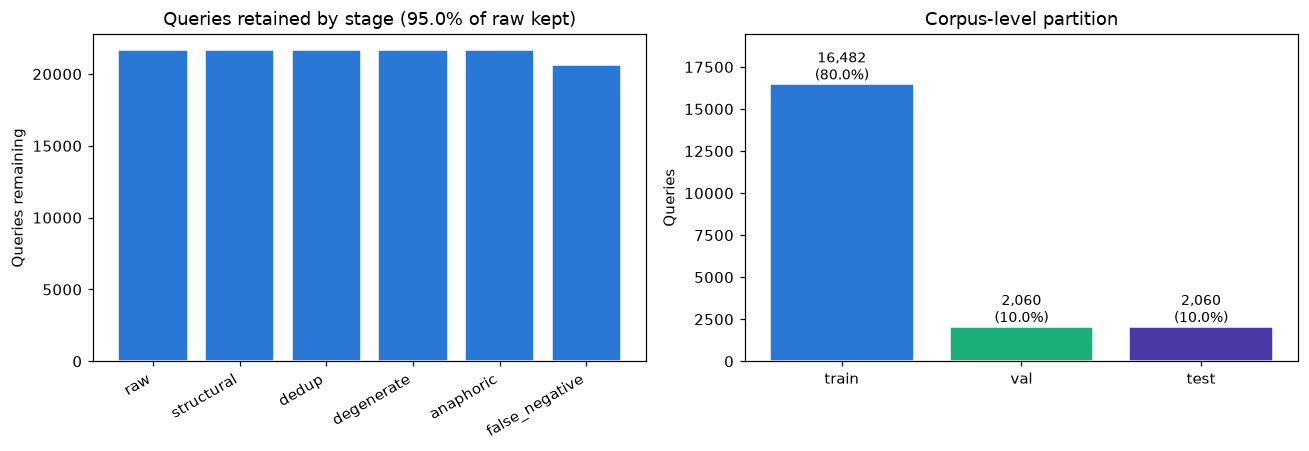

In [25]:
stage_order = ["00_raw", "01_structural", "02_dedup", "03_degenerate",
               "04_anaphoric", "06_false_negative"]
query_track = (
    ledger_df[ledger_df["unit"] == "queries"]
    .drop_duplicates(subset="stage", keep="last")
    .set_index("stage")
    .reindex(stage_order)["remaining"]
    .ffill()
)
pair_track = (
    ledger_df[ledger_df["unit"] == "(query, negative) pairs"]
    .drop_duplicates(subset="stage", keep="last")
    .set_index("stage")["remaining"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].bar(range(len(query_track)), query_track.values, color="#2a78d6", edgecolor="white")
axes[0].set_xticks(range(len(query_track)))
axes[0].set_xticklabels([s.split("_", 1)[1] for s in query_track.index], rotation=30, ha="right")
retention = query_track.iloc[-1] / query_track.iloc[0]
axes[0].set_title(f"Queries retained by stage ({retention:.1%} of raw kept)")
axes[0].set_ylabel("Queries remaining")

split_counts = df["split"].value_counts().reindex(list(fracs), fill_value=0)
axes[1].bar(split_counts.index, split_counts.values,
            color=["#2a78d6", "#1baf7a", "#4a3aa7"], edgecolor="white")
for i, v in enumerate(split_counts.values):
    axes[1].text(i, v, f"{v:,}\n({v / len(df):.1%})", ha="center", va="bottom", fontsize=9)
axes[1].set_title("Corpus-level partition")
axes[1].set_ylabel("Queries")
axes[1].set_ylim(0, split_counts.max() * 1.18)

fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/fig6_cleaning_and_splits.png", dpi=150)
plt.show()

## 11. Data cleaning summary

| Stage | Unit removed | Rationale |
|---|---|---|
| Structural integrity | Queries with null/empty text, orphaned `pos_id`, duplicate `query_id`; negatives equal to the positive or pointing outside the corpus | Contradictory supervision — the same passage as both positive and negative for one anchor gives directly opposing gradients |
| Passage deduplication | Redundant passage identifiers whose normalized text is identical | Prevents a training passage from reappearing in the test corpus under a different id, which would silently inflate test metrics |
| Degenerate positives | Queries whose positive is under 6 tokens | Too little semantic content to anchor a contrastive pair; fragments are retained in the corpus and as negatives, where they are realistic |
| Anaphoric queries | Queries with an unresolved referring expression, an underspecified predicate, and no specific clinical entity | No unique gold passage exists, so Recall@k and nDCG@10 penalize correct retrievals; validated against a hand-labeled stratified sample |
| False negatives | (query, negative) pairs above the calibrated bge-m3 similarity cutoff | Contrastive loss would push apart a query and a passage that answers it; threshold derived from the 5th percentile of true positive-pair similarity |
| Negative cap | Negatives beyond 8 per query | Bounds epoch size; seeded uniform sample so hard-negative selection stays with Module 6's mining step |

**Interfaces to the rest of the project.** `train.jsonl` feeds the bi-encoder fine-tune
(Experiment A, Module 5) and, after Module 6 re-mines hard negatives from the fine-tuned
retriever, the reranker fine-tune (Experiment B). `val.jsonl` drives the hyperparameter sweep and
early stopping. `test.jsonl` and the corresponding retrieval corpus stay untouched until the
final evaluation of all six configurations, so the comparison table reports held-out numbers.

**Limitations to carry into the report.** The anaphoric filter's precision and recall come from
a 150-item sample, so the reported rate has a confidence interval of a few percentage points —
worth stating rather than presenting the point estimate alone. False-negative screening covers
only negatives reused 20 or more times, which is a deliberate compute trade-off: mislabeled
negatives in the low-reuse tail survive, and the 20-reuse cutoff is inherited from the EDA
distribution rather than independently optimized. Screening with stock bge-m3 also inherits that
model's blind spots — pairs it cannot tell apart are the pairs it cannot flag, which biases the
surviving errors toward the cases the fine-tuned model will also find hardest. Finally, the
splits are stratified by nothing: component-level assignment and stratification cannot both be
satisfied exactly, and the leakage guarantee is the more important of the two.